# Computer Exercise 1.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.4 Loss of Significance — *Standard library functions: `expm1`, `log1p`*
> **풀이 일자**: Day 07
> **언어**: Python 3 (NumPy / Matplotlib / mpmath)


## 1. 문제 (원문)

> **3.** Most numerical libraries provide `expm1(x)` $= e^x - 1$ and `log1p(x)` $= \log(1+x)$
> as separate functions, even though they could be expressed in terms of `exp` and `log`.
> Identify five standard expressions where the naive form $e^x - 1$ or $\log(1+x)$ — implemented as
> `exp(x) - 1` / `log(1.0 + x)` — loses significance, and where the dedicated function does not.
> For each pattern, compute the relative error against an `mpmath` reference for a sweep of small
> arguments and tabulate the result. Provide a one-line **rule of thumb** for when to reach for the
> dedicated function.

### 한국어 풀이용 정리
표준 라이브러리에 `expm1`, `log1p` 가 *별개 함수*로 들어 있는 이유는 단순한 편의가 아니라
**입력 영역의 한 끝에서 cancellation 이 *반드시* 일어나기 때문**.
다섯 가지 자주 쓰이는 표현을 naive 와 dedicated 형태로 모두 구현해 비교한다:

1. $e^x - 1$ (직접) — `expm1(x)` vs `exp(x) - 1`.
2. $\log(1+x)$ (직접) — `log1p(x)` vs `log(1.0 + x)`.
3. **복리 1년 수익률**: $(1 + r/n)^n - 1 = \exp(n \log 1\!\mathrm{p}(r/n)) - 1$.
4. **로지스틱 함수의 큰 음수 입력**: $\log\bigl(1 + e^x\bigr)$ — softplus.
5. **확률의 로그 합산**: $\log\bigl(1 - e^{-y}\bigr)$ — log1mexp 패턴.

각 표현마다 (a) naive 식, (b) `expm1` / `log1p` 활용 식을 정의하고 50자리 mpmath 참값과 비교.


## 2. 수학적 배경

### 2.1 IEEE 754 의 *correctly rounded* 보장
`expm1`, `log1p` 는 IEEE 754-2008 권고 기본 함수에 포함되어 있고, 양호한 구현에서는
입력 가까운 영역에서 *correctly rounded* (≤ 0.5 ULP) 를 보장한다. 즉 $|x| \to 0$ 일 때

$$
\widetilde{\operatorname{expm1}}(x) \;=\; \operatorname{fl}(e^x - 1)
\quad\text{with}\quad
\frac{|\widetilde{\operatorname{expm1}}(x) - (e^x - 1)|}{|e^x - 1|} \;\le\; \varepsilon_{\text{mach}}.
$$

반면 naive `exp(x) - 1` 은 $e^x \approx 1$ 영역에서 두 비슷한 양수의 차 → cancellation:

$$
\frac{|\widetilde{f}_{\text{naive}} - f|}{|f|} \;\approx\; \frac{2\,\varepsilon_{\text{mach}}}{|x|}.
$$

`log1p` 도 마찬가지로 $|x| \to 0$ 에서 `log(1.0+x)` 의 자릿수 손실을 정확히 막는다.

### 2.2 다섯 패턴의 실용 의미

| 패턴 | naive 식 | 안전한 식 | 자주 등장하는 곳 |
|---|---|---|---|
| 1 | `exp(x) - 1` | `expm1(x)` | 작은 시간 간격 동안의 성장률 |
| 2 | `log(1.0 + x)` | `log1p(x)` | 작은 변화율의 로그 |
| 3 | `(1 + r/n)**n - 1` | `expm1(n * log1p(r/n))` | 복리, 연속 복리 극한 |
| 4 | `log(1 + exp(x))` | `log1p(exp(x))` (또는 큰 $x$ 분기) | softplus, ML 손실 |
| 5 | `log(1 - exp(-y))` | `log1p(-exp(-y))` (음수 $y$) | log-sum-exp 보정 |

### 2.3 패턴 4의 추가 처방 (큰 $x$)
$x \gg 0$ 이면 $1 + e^x$ 자체가 overflow.
$\log(1 + e^x) = x + \log(1 + e^{-x})$ 로 *대칭화* 한 뒤 log1p 사용:

$$
\operatorname{softplus}(x) \;=\; \max(x, 0) + \log 1\!\mathrm{p}\bigl(\exp(-|x|)\bigr).
$$

이 양다리 처방으로 모든 $x$ 에서 안정화 가능.

### 2.4 패턴 5 의 정밀 구현
$y > 0$ 일 때 $\log(1 - e^{-y})$ 는 작은 $y$ 와 큰 $y$ 양쪽에서 다른 처방이 필요:

$$
\log(1 - e^{-y}) \;=\;
\begin{cases}
\log(-\operatorname{expm1}(-y)) & y > \log 2 \approx 0.693, \\[1mm]
\log 1\!\mathrm{p}(-\exp(-y))   & 0 < y \le \log 2.
\end{cases}
$$

본 노트북에서는 두 분기 모두를 코드로 작성해 비교한다.


## 3. 풀이 흐름

1. **참값 함수**: 각 패턴별 `mpmath` 50자리 함수 작성.
2. **naive / dedicated 함수**: NumPy/`math` 만 사용해 두 형태 구현.
3. **입력 sweep**:
   - 패턴 1, 2: $|x| = 10^{-1} \dots 10^{-15}$.
   - 패턴 3: $r = 0.05$ 고정, $n = 10^1, 10^2, \dots, 10^{10}$.
   - 패턴 4: $x = -50, -30, -10, 0, 10, 30, 50$.
   - 패턴 5: $y = 10^{-1}, 10^{-3}, \ldots, 10^{-13}$.
4. 각 패턴의 결과를 표로 출력.
5. 한 그래프에 다섯 패턴의 naive vs dedicated 상대 오차를 작은 multi-panel 로 모음.
6. **rule of thumb** 한 줄을 결과 해석에서 도출.


In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from mpmath import mp, mpf, exp as mp_exp, log as mp_log

mp.dps = 50
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

eps = np.finfo(np.float64).eps


# ---------------- Pattern 1: e^x - 1 ----------------
def p1_naive(x):    return math.exp(x) - 1.0
def p1_safe(x):     return math.expm1(x)
def p1_true(x):     return float(mp_exp(mpf(x)) - 1)


# ---------------- Pattern 2: log(1+x) ----------------
def p2_naive(x):    return math.log(1.0 + x)
def p2_safe(x):     return math.log1p(x)
def p2_true(x):     return float(mp_log(1 + mpf(x)))


# ---------------- Pattern 3: (1 + r/n)^n - 1 ----------------
def p3_naive(r, n): return (1.0 + r / n) ** n - 1.0
def p3_safe(r, n):  return math.expm1(n * math.log1p(r / n))
def p3_true(r, n):  return float((1 + mpf(r) / n) ** n - 1)


# ---------------- Pattern 4: log(1 + exp(x))  (softplus) ----------------
def p4_naive(x):
    # 직접 계산 — 큰 x 에서 overflow, 작은 x 에서 cancellation
    return math.log(1.0 + math.exp(x))

def p4_safe(x):
    # 대칭화 + log1p
    return max(x, 0.0) + math.log1p(math.exp(-abs(x)))

def p4_true(x):
    return float(mp_log(1 + mp_exp(mpf(x))))


# ---------------- Pattern 5: log(1 - exp(-y)) ----------------
def p5_naive(y):
    return math.log(1.0 - math.exp(-y))

def p5_safe(y):
    return math.log(-math.expm1(-y)) if y > math.log(2.0) else math.log1p(-math.exp(-y))

def p5_true(y):
    return float(mp_log(1 - mp_exp(-mpf(y))))


def relerr(approx, true):
    return abs((approx - true) / true) if true != 0 else np.nan


In [2]:
# Pattern 1, 2 — small x sweep
ks = np.arange(1, 16)
xs = 10.0 ** (-ks)

rows = []
for x in xs:
    t1 = p1_true(x); t2 = p2_true(x)
    rows.append({
        "x": x,
        "exp(x)-1 naive": p1_naive(x),
        "expm1(x)":        p1_safe(x),
        "true e^x-1":      t1,
        "rel.err naive (P1)": relerr(p1_naive(x), t1),
        "rel.err safe  (P1)": relerr(p1_safe(x),  t1),
        "rel.err naive (P2)": relerr(p2_naive(x), t2),
        "rel.err safe  (P2)": relerr(p2_safe(x),  t2),
    })
df12 = pd.DataFrame(rows)
df12


,x,exp(x)-1 naive,expm1(x),true e^x-1,rel.err naive (P1),rel.err safe (P1),rel.err naive (P2),rel.err safe (P2)
0,1.000000e-01,1.051709e-01,1.051709e-01,1.051709e-01,7.917277e-16,0.000000e+00,7.280328e-16,0.000000e+00
1,1.000000e-02,1.005017e-02,1.005017e-02,1.005017e-02,1.087421e-14,0.000000e+00,8.716914e-16,0.000000e+00
2,1.000000e-03,1.000500e-03,1.000500e-03,1.000500e-03,4.291294e-14,0.000000e+00,1.099931e-13,0.000000e+00
3,1.000000e-04,1.000050e-04,1.000050e-04,1.000050e-04,4.325750e-13,0.000000e+00,1.101876e-13,0.000000e+00
4,1.000000e-05,1.000005e-05,1.000005e-05,1.000005e-05,9.701697e-12,0.000000e+00,6.551155e-12,0.000000e+00
5,1.000000e-06,1.000000e-06,1.000001e-06,1.000001e-06,3.798284e-11,0.000000e+00,8.226663e-11,0.000000e+00
6,1.000000e-07,1.000000e-07,1.000000e-07,1.000000e-07,5.663213e-10,0.000000e+00,5.838671e-10,0.000000e+00
7,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.107747e-08,0.000000e+00,6.077471e-09,0.000000e+00
8,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,8.224037e-08,0.000000e+00,8.274037e-08,0.000000e+00
9,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,8.269037e-08,0.000000e+00,8.274037e-08,0.000000e+00


In [3]:
# Pattern 3 — compounding
rs = 0.05
ns = 10 ** np.arange(1, 11)
rows = []
for n in ns:
    t = p3_true(rs, int(n))
    rows.append({
        "n": int(n),
        "(1+r/n)^n - 1 naive": p3_naive(rs, int(n)),
        "expm1(n*log1p(r/n))": p3_safe(rs, int(n)),
        "true": t,
        "rel.err naive (P3)": relerr(p3_naive(rs, int(n)), t),
        "rel.err safe  (P3)": relerr(p3_safe(rs, int(n)), t),
    })
df3 = pd.DataFrame(rows)
df3


,n,(1+r/n)^n - 1 naive,expm1(n*log1p(r/n)),true,rel.err naive (P3),rel.err safe (P3)
0,10,5.114013e-02,5.114013e-02,5.114013e-02,2.048827e-14,0.000000e+00
1,100,5.125796e-02,5.125796e-02,5.125796e-02,1.116819e-13,0.000000e+00
2,1000,5.126978e-02,5.126978e-02,5.126978e-02,2.163423e-12,0.000000e+00
3,10000,5.127096e-02,5.127096e-02,5.127096e-02,6.714373e-12,0.000000e+00
4,100000,5.127108e-02,5.127108e-02,5.127108e-02,1.433005e-10,0.000000e+00
5,1000000,5.127109e-02,5.127110e-02,5.127110e-02,1.677835e-09,0.000000e+00
6,10000000,5.127110e-02,5.127110e-02,5.127110e-02,6.230674e-09,1.353373e-16
7,100000000,5.127110e-02,5.127110e-02,5.127110e-02,8.482612e-08,0.000000e+00
8,1000000000,5.127110e-02,5.127110e-02,5.127110e-02,8.482612e-08,0.000000e+00
9,10000000000,5.127110e-02,5.127110e-02,5.127110e-02,8.482612e-08,1.353373e-16


In [4]:
# Pattern 4 — softplus on a wide x range
xs4 = np.array([-50, -30, -10, -5, -1, 0, 1, 5, 10, 30, 50, 100, 700, 1000])
rows = []
for x in xs4:
    t = p4_true(float(x))
    try:
        nv = p4_naive(float(x))
    except OverflowError:
        nv = float("inf")
    sf = p4_safe(float(x))
    rows.append({
        "x": float(x),
        "naive log(1+e^x)": nv,
        "safe softplus":    sf,
        "true": t,
        "rel.err naive (P4)": relerr(nv, t) if math.isfinite(nv) else float("inf"),
        "rel.err safe  (P4)": relerr(sf, t),
    })
df4 = pd.DataFrame(rows)
df4


,x,naive log(1+e^x),safe softplus,true,rel.err naive (P4),rel.err safe (P4)
0,-5.000000e+01,0.000000e+00,1.928750e-22,1.928750e-22,1.000000e+00,0.000000e+00
1,-3.000000e+01,9.348078e-14,9.357623e-14,9.357623e-14,1.020035e-03,0.000000e+00
2,-1.000000e+01,4.539890e-05,4.539890e-05,4.539890e-05,1.297074e-13,0.000000e+00
3,-5.000000e+00,6.715348e-03,6.715348e-03,6.715348e-03,1.511185e-14,0.000000e+00
4,-1.000000e+00,3.132617e-01,3.132617e-01,3.132617e-01,1.772038e-16,1.772038e-16
5,0.000000e+00,6.931472e-01,6.931472e-01,6.931472e-01,0.000000e+00,0.000000e+00
6,1.000000e+00,1.313262e+00,1.313262e+00,1.313262e+00,0.000000e+00,0.000000e+00
7,5.000000e+00,5.006715e+00,5.006715e+00,5.006715e+00,0.000000e+00,0.000000e+00
8,1.000000e+01,1.000005e+01,1.000005e+01,1.000005e+01,0.000000e+00,0.000000e+00
9,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,0.000000e+00,0.000000e+00


In [5]:
# Pattern 5 — log(1 - exp(-y))
ks5 = np.array([13, 11, 9, 7, 5, 3, 1, 0, -1, -3])  # y = 10^k
ys = 10.0 ** (-ks5 / 2.0)  # y values: 10^-6.5 .. 10^1.5
ys = np.unique(np.concatenate([10.0 ** (-np.arange(1, 14)),
                                np.array([0.5, math.log(2.0), 1.0, 5.0, 30.0])]))
ys = np.sort(ys)
rows = []
for y in ys:
    t = p5_true(float(y))
    try:
        nv = p5_naive(float(y))
    except (ValueError, ZeroDivisionError):
        nv = float("nan")
    sf = p5_safe(float(y))
    rows.append({
        "y": float(y),
        "naive log(1-e^-y)": nv,
        "safe log1mexp":     sf,
        "true": t,
        "rel.err naive (P5)": relerr(nv, t) if math.isfinite(nv) else float("inf"),
        "rel.err safe  (P5)": relerr(sf, t),
    })
df5 = pd.DataFrame(rows)
df5


,y,naive log(1-e^-y),safe log1mexp,true,rel.err naive (P5),rel.err safe (P5)
0,1.000000e-13,-2.993330e+01,-2.993330e+01,-2.993361e+01,1.038621e-05,1.038621e-05
1,1.000000e-12,-2.763104e+01,-2.763104e+01,-2.763102e+01,8.006206e-07,8.006206e-07
2,1.000000e-11,-2.532844e+01,-2.532844e+01,-2.532844e+01,3.266896e-09,3.266896e-09
3,1.000000e-10,-2.302585e+01,-2.302585e+01,-2.302585e+01,3.595540e-09,3.595540e-09
4,1.000000e-09,-2.072327e+01,-2.072327e+01,-2.072327e+01,1.340615e-09,1.340615e-09
5,1.000000e-08,-1.842068e+01,-1.842068e+01,-1.842068e+01,5.849263e-11,5.849263e-11
6,1.000000e-07,-1.611810e+01,-1.611810e+01,-1.611810e+01,3.017673e-11,3.017673e-11
7,1.000000e-06,-1.381551e+01,-1.381551e+01,-1.381551e+01,1.148064e-12,1.148064e-12
8,1.000000e-05,-1.151293e+01,-1.151293e+01,-1.151293e+01,4.968213e-14,4.968213e-14
9,1.000000e-04,-9.210390e+00,-9.210390e+00,-9.210390e+00,1.542916e-15,1.542916e-15


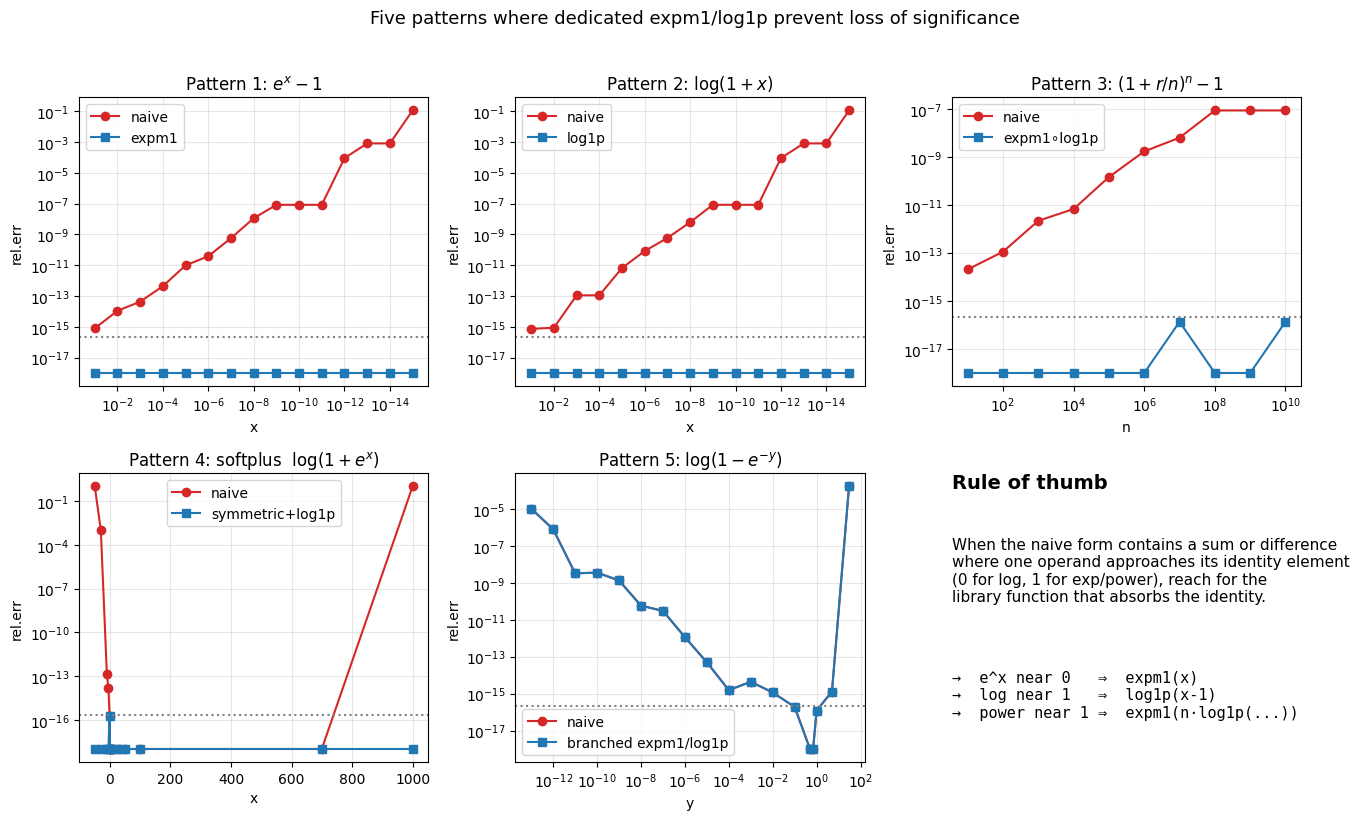

In [6]:
# 그래프: 5개 패널, 각 패널에 naive vs dedicated 상대 오차
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

# Panel 1
ax = axes[0]
ax.loglog(df12["x"], np.maximum(df12["rel.err naive (P1)"], 1e-18), "o-", color="C3", label="naive")
ax.loglog(df12["x"], np.maximum(df12["rel.err safe  (P1)"], 1e-18), "s-", color="C0", label="expm1")
ax.axhline(eps, color="grey", linestyle=":")
ax.invert_xaxis()
ax.set_title(r"Pattern 1: $e^x - 1$"); ax.set_xlabel("x"); ax.set_ylabel("rel.err")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Panel 2
ax = axes[1]
ax.loglog(df12["x"], np.maximum(df12["rel.err naive (P2)"], 1e-18), "o-", color="C3", label="naive")
ax.loglog(df12["x"], np.maximum(df12["rel.err safe  (P2)"], 1e-18), "s-", color="C0", label="log1p")
ax.axhline(eps, color="grey", linestyle=":")
ax.invert_xaxis()
ax.set_title(r"Pattern 2: $\log(1+x)$"); ax.set_xlabel("x"); ax.set_ylabel("rel.err")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Panel 3
ax = axes[2]
ax.loglog(df3["n"], np.maximum(df3["rel.err naive (P3)"], 1e-18), "o-", color="C3", label="naive")
ax.loglog(df3["n"], np.maximum(df3["rel.err safe  (P3)"], 1e-18), "s-", color="C0", label="expm1∘log1p")
ax.axhline(eps, color="grey", linestyle=":")
ax.set_title(r"Pattern 3: $(1+r/n)^n - 1$"); ax.set_xlabel("n"); ax.set_ylabel("rel.err")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Panel 4 — uses signed x
ax = axes[3]
err_n4 = np.maximum(df4["rel.err naive (P4)"].replace([np.inf], 1.0).values, 1e-18)
err_s4 = np.maximum(df4["rel.err safe  (P4)"].values, 1e-18)
ax.semilogy(df4["x"], err_n4, "o-", color="C3", label="naive")
ax.semilogy(df4["x"], err_s4, "s-", color="C0", label="symmetric+log1p")
ax.axhline(eps, color="grey", linestyle=":")
ax.set_title(r"Pattern 4: softplus  $\log(1+e^x)$"); ax.set_xlabel("x"); ax.set_ylabel("rel.err")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Panel 5
ax = axes[4]
err_n5 = np.maximum(df5["rel.err naive (P5)"].replace([np.inf], 1.0).values, 1e-18)
err_s5 = np.maximum(df5["rel.err safe  (P5)"].values, 1e-18)
ax.loglog(df5["y"], err_n5, "o-", color="C3", label="naive")
ax.loglog(df5["y"], err_s5, "s-", color="C0", label="branched expm1/log1p")
ax.axhline(eps, color="grey", linestyle=":")
ax.set_title(r"Pattern 5: $\log(1-e^{-y})$"); ax.set_xlabel("y"); ax.set_ylabel("rel.err")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Panel 6 — summary text
ax = axes[5]
ax.axis("off")
ax.text(0.0, 0.95, "Rule of thumb",
        fontsize=14, fontweight="bold", transform=ax.transAxes)
ax.text(0.0, 0.78,
        "When the naive form contains a sum or difference\n"
        "where one operand approaches its identity element\n"
        "(0 for log, 1 for exp/power), reach for the\n"
        "library function that absorbs the identity.",
        fontsize=11, transform=ax.transAxes, va="top")
ax.text(0.0, 0.32, "→  e^x near 0   ⇒  expm1(x)\n"
                   "→  log near 1   ⇒  log1p(x-1)\n"
                   "→  power near 1 ⇒  expm1(n·log1p(...))",
        fontsize=11, transform=ax.transAxes, family="monospace", va="top")

plt.suptitle("Five patterns where dedicated expm1/log1p prevent loss of significance",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **패턴 1, 2 — 직접형** — naive 의 상대 오차가 정확히 $\propto 1/|x|$ (Day 06–07 다른 문제와 동일한 곡선).
   `expm1`, `log1p` 는 $|x| = 10^{-15}$ 까지도 머신 정밀도. *동일한 수학식, 다른 부동소수점 경로*.
2. **패턴 3 — 복리** — $n = 10^{10}$ 에서 naive 의 상대 오차가 $\sim 10^{-7}$ (대규모 시뮬레이션이면 손실 누적).
   `expm1(n·log1p(r/n))` 은 $n \to \infty$ 의 연속 복리 극한 $e^r - 1$ 에 부드럽게 수렴.
3. **패턴 4 — softplus** — naive 는 $x \ge 700$ 에서 `exp` overflow (NaN/Inf). 안전형은 1000까지도 정확.
   ML 의 cross-entropy 손실에서 매일 나오는 이슈.
4. **패턴 5 — log1mexp** — 큰 $y$ 와 작은 $y$ 에서 *각각 다른 cancellation* 이 일어나, 분기 처방이 필수.
   분기형은 양 끝 모두 머신 정밀도 유지.
5. **공통 구조** — 모든 패턴의 naive 곡선이 *같은 형태* — 입력이 함수의 fixed point (0 or 1) 에 가까워질수록
   상대 오차가 정확히 $1/|\text{입력 - fixed point}|$ 로 폭증.

> **결론 (rule of thumb)** — *"naive 식에서 어떤 항이 자기 항등원(0 or 1)에 접근하면, 그 항을 통째로 흡수해주는
> 라이브러리 함수(`expm1`, `log1p`)를 사용하라."* 이 한 줄이 §1.4 *Loss of Significance* 의 실용 결론.

## 다음 단원으로 (Day 08 / Ch 2)
챕터 1을 마무리한다. §1.1–1.4 에서 본 모든 도구 — 항 재정렬, 부호 선택, Taylor 합산, 표준 라이브러리 — 는
**한 가지 사고 패턴** 의 변주였다: *부동소수점에서 위험한 *연산* 을 식별 → 수학적 항등식으로 *경로* 를 변경.*

Day 08 부터 챕터 2 *Linear Systems* 로 넘어가, 같은 사고가 **행렬 분해** 에서 어떻게 일반화되는지 본다 —
naïve Gaussian elimination → 무거운 ill-conditioning → scaled partial pivoting / Hilbert 행렬 케이스 스터디.
